In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [13]:
client_data = pd.read_csv('./customer_data.csv')
client_data

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,1,56,89,47,Libros
1,2,69,91,86,Hogar
2,3,46,46,23,Electrónica
3,4,32,28,66,Libros
4,5,60,81,27,Electrónica
...,...,...,...,...,...
195,196,69,77,99,Libros
196,197,30,86,36,Electrónica
197,198,58,65,82,Electrónica
198,199,20,43,96,Alimentos


In [14]:
client_data.isnull().sum()

ID Cliente                        0
Edad                              0
Ingresos Anuales (k$)             0
Puntuación de Gasto (1-100)       0
Categoría de Producto Favorito    0
dtype: int64

In [15]:
print(f'SHAPE:\n{client_data.shape}\n')

print('INFO:')
client_data.info()

print('\nDESCRIBE:')
print(client_data.describe())

SHAPE:
(200, 5)

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ID Cliente                      200 non-null    int64 
 1   Edad                            200 non-null    int64 
 2   Ingresos Anuales (k$)           200 non-null    int64 
 3   Puntuación de Gasto (1-100)     200 non-null    int64 
 4   Categoría de Producto Favorito  200 non-null    object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

DESCRIBE:
       ID Cliente       Edad  Ingresos Anuales (k$)  \
count  200.000000  200.00000             200.000000   
mean   100.500000   43.42500              69.580000   
std     57.879185   14.94191              29.693808   
min      1.000000   18.00000              20.000000   
25%     50.750000   31.00000              43.750000   
50%    100.500000   43.50000              69.500000   
75%    

In [16]:
# Normalize data
scaler = MinMaxScaler()
normalized_d = scaler.fit_transform(client_data[["Edad", "Ingresos Anuales (k$)", "Puntuación de Gasto (1-100)"]])
normalized_d[:5]


array([[0.74509804, 0.6969697 , 0.46938776],
       [1.        , 0.71717172, 0.86734694],
       [0.54901961, 0.26262626, 0.2244898 ],
       [0.2745098 , 0.08080808, 0.66326531],
       [0.82352941, 0.61616162, 0.26530612]])

In [17]:
# Define PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(normalized_d)


In [18]:
# Apply SVD
U, Sigma, VT = np.linalg.svd(normalized_d)

# Select the first two singular components to reduce their dimensions
k = 2
svd_results= U[:, :k] * Sigma[:k]

## K-means Clustering and Hierarchical Clustering

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(normalized_d)

# Apply hierachical clustering
linked = linkage(normalized_d, method='ward')

C:\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualizing data

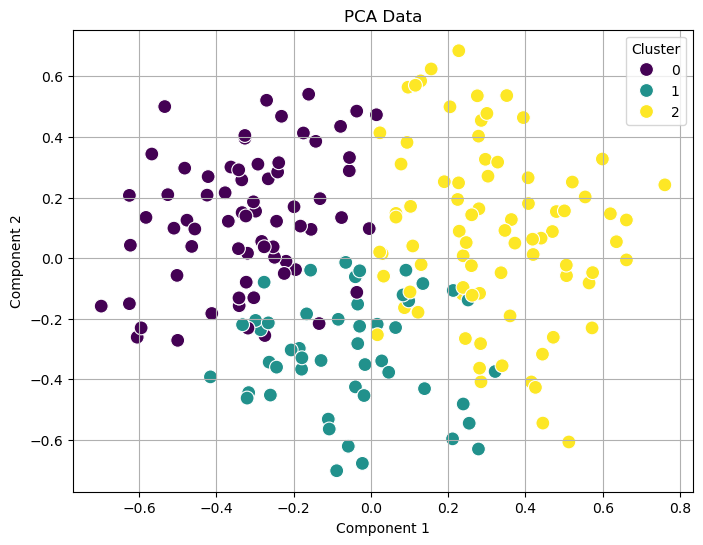

In [20]:
# Scatter plot for PCA results
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:,1], hue=kmeans_clusters, palette='viridis', s=100)
plt.title('PCA Data')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Cluster')
plt.grid(True)


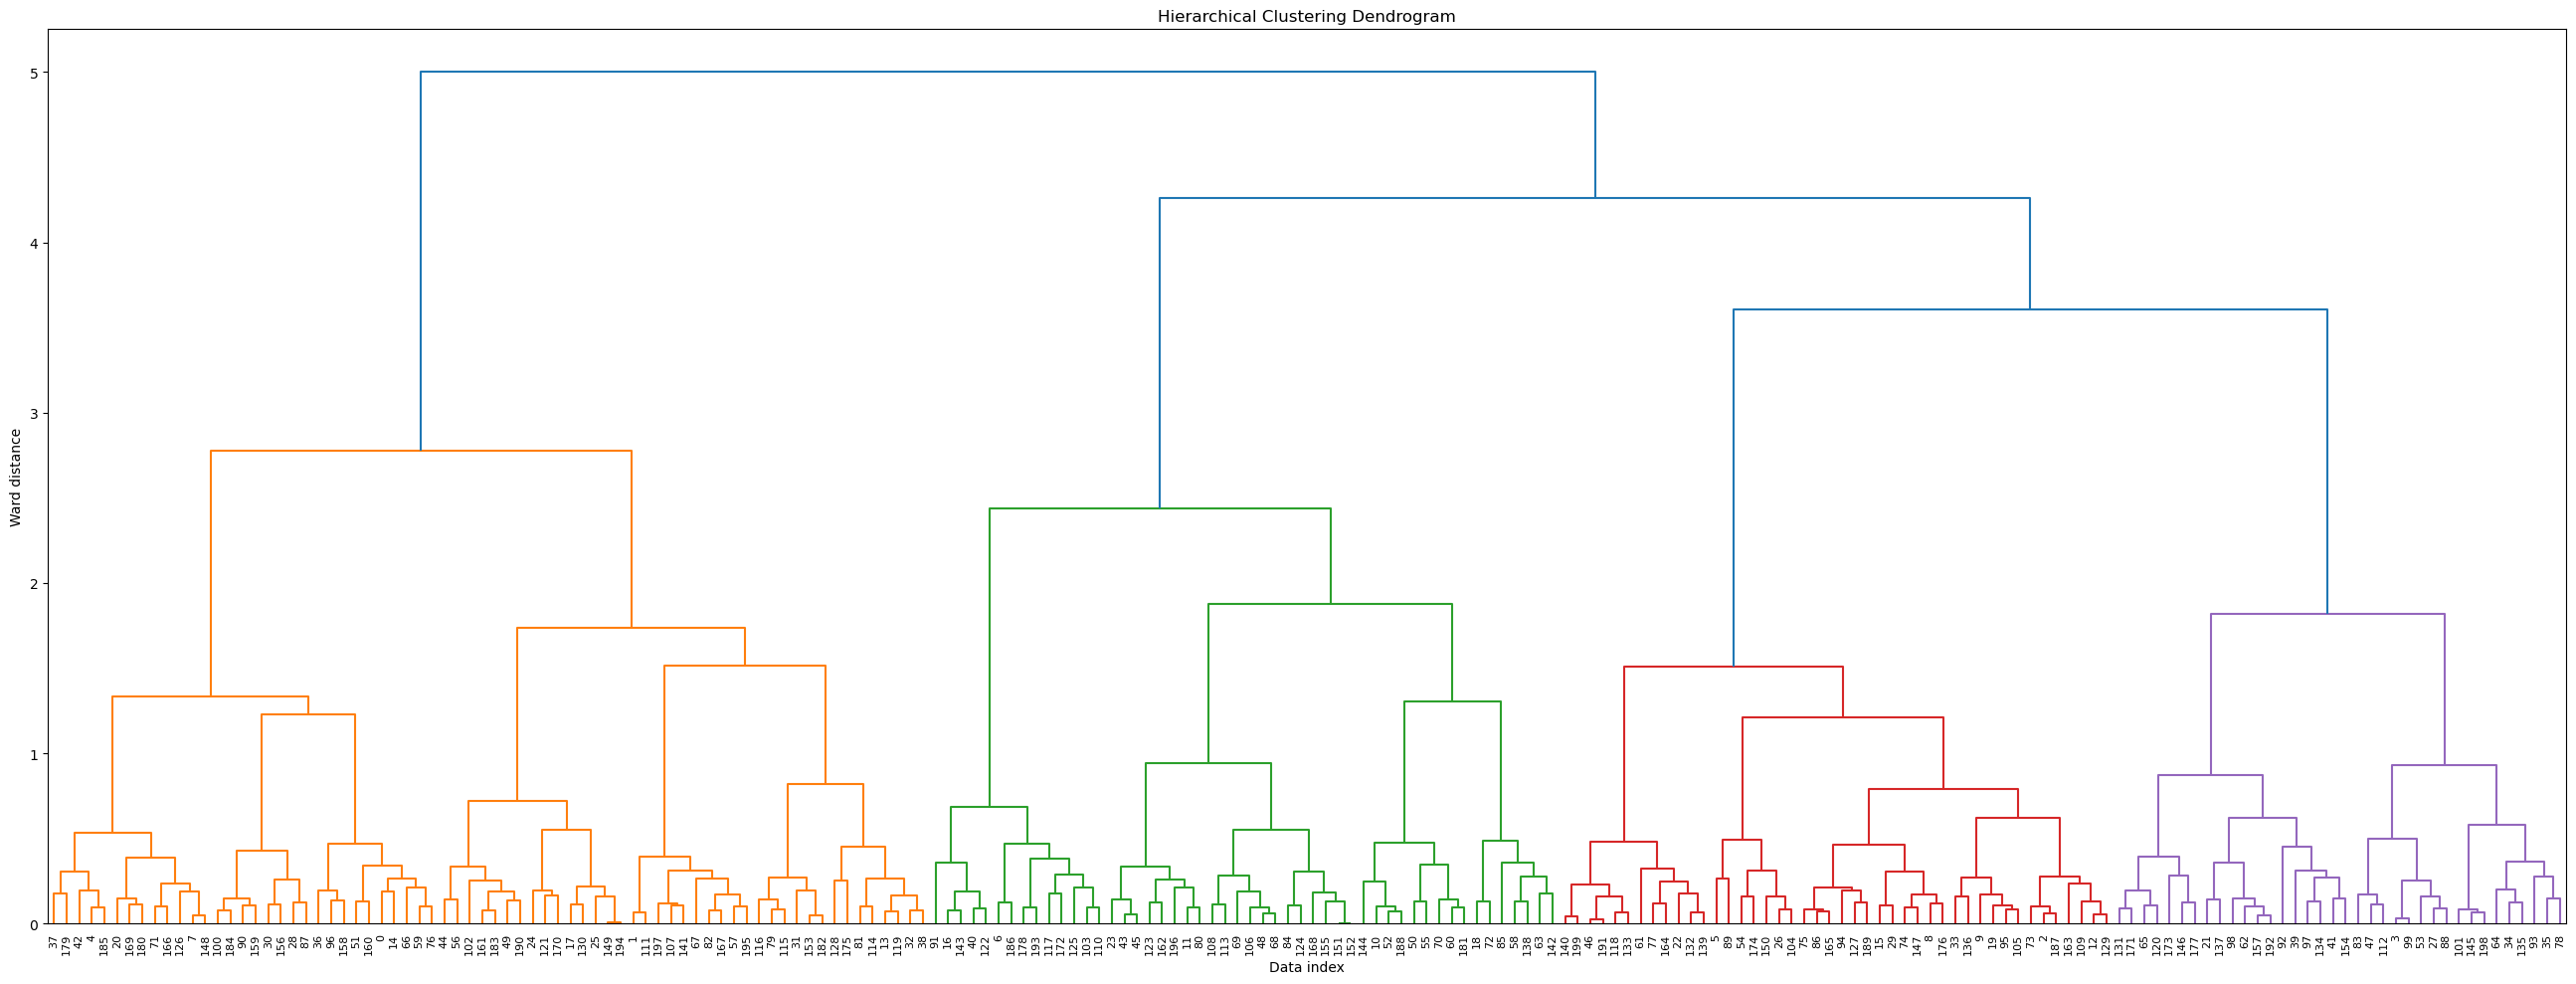

In [24]:
plt.figure(figsize=(26, 10))  # make it wider

dendrogram(
    linked,
    leaf_rotation=90,     # rotate labels
    leaf_font_size=8      # smaller text
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data index')
plt.ylabel('Ward distance')
plt.axhline(y=10, color='r', linestyle='--')

plt.tight_layout()
plt.show()


## Interpratation

In [22]:
# Cluster analysis

cluster_info = pd.DataFrame({
    'Cluster': kmeans_clusters,
    'Age': client_data['Edad'],
    'Income': client_data['Ingresos Anuales (k$)'],
    'Spent': client_data['Puntuación de Gasto (1-100)'],
    'Favorite_Category': client_data['Categoría de Producto Favorito']
})

# Means by cluster
for cluster in cluster_info['Cluster'].unique():

    cluster_data = cluster_info[
        cluster_info['Cluster'] == cluster
    ]

    print(f"\nCluster {cluster}:")

    print(f" - Age Mean: {cluster_data['Age'].mean():.2f}")
    print(f" - Income Mean: {cluster_data['Income'].mean():.2f}")
    print(f" - Spent Mean: {cluster_data['Spent'].mean():.2f}")

    print("\n Favorite categories:")

    print(
        cluster_data['Favorite_Category']
        .value_counts()
    )


Cluster 2:
 - Age Mean: 49.67
 - Income Mean: 97.33
 - Spent Mean: 62.00

 Favorite categories:
Favorite_Category
Libros         21
Electrónica    20
Ropa           15
Hogar          12
Alimentos      12
Name: count, dtype: int64

Cluster 0:
 - Age Mean: 42.97
 - Income Mean: 52.51
 - Spent Mean: 20.17

 Favorite categories:
Favorite_Category
Libros         20
Hogar          16
Electrónica    14
Alimentos      10
Ropa           10
Name: count, dtype: int64

Cluster 1:
 - Age Mean: 34.06
 - Income Mean: 49.08
 - Spent Mean: 72.20

 Favorite categories:
Favorite_Category
Libros         12
Electrónica    11
Alimentos      11
Hogar          10
Ropa            6
Name: count, dtype: int64



# MARKETING SUGGESTIONS BASED ON CUSTOMER CLUSTERS


### Cluster 2: High-Income Mature Consumers
---------------------------------------
Characteristics:
- Older customers
- Highest average income
- Medium-high spending behavior
- Strong interest in books and electronics

Marketing Suggestions:
- Promote premium and high-quality products
- Offer loyalty or VIP programs
- Create personalized recommendations
- Focus on convenience and product quality
- Use email marketing for exclusive offers

Potential Campaigns:
- Premium electronics bundles
- Smart home promotions
- Reading and technology packages


### Cluster 0: Low-Spending Practical Shoppers
------------------------------------------
Characteristics:
- Middle-aged customers
- Medium income
- Lowest spending behavior
- Interest mainly in books and home products

Marketing Suggestions:
- Offer discounts and coupons
- Use seasonal promotions
- Create bundle offers
- Encourage repeat purchases with rewards
- Use retargeting advertisements

Potential Campaigns:
- Buy more, save more
- Home essentials discounts
- Seasonal sales campaigns



### Cluster 1: Young Active Spenders
--------------------------------
Characteristics:
- Youngest customer group
- Medium income
- Highest spending behavior
- Balanced interests in books, electronics, and food

Marketing Suggestions:
- Focus on social media marketing
- Use mobile-friendly campaigns
- Promote flash sales and limited-time offers
- Implement gamified rewards systems
- Recommend trending products

Potential Campaigns:
- Weekly tech deals
- Food and lifestyle bundles
- Student or young professional promotions



# Key Business Insight
--------------------
Customer income does not fully determine spending behavior.

Cluster 1 spends the most despite not having the highest income,
while Cluster 0 spends the least with similar income levels.

This suggests that customer engagement and purchasing behavior
are influenced by factors beyond income alone.

